In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
#Carga desde un archivo .csv sin indice
bitacora= pd.read_csv('Analisis GAC Full7agosto 2026(Bitacora de Piso).csv') 

In [10]:
#Verificamos información del DataFrame
bitacora.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 30 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Fecha                                       198 non-null    str    
 1   Nombre Cliente                              197 non-null    str    
 2   Telefono                                    0 non-null      float64
 3   Asesor                                      196 non-null    str    
 4   Esatus Lead                                 197 non-null    str    
 5   PDM                                         234 non-null    bool   
 6   SDC                                         216 non-null    object 
 7   Estatus de SDC                              2 non-null      str    
 8   Venta                                       216 non-null    object 
 9   Temperatura                                 10 non-null     str    
 10  Inter Gerente            

In [11]:
#Imprimo los primeros 5 registro del dataframe
bitacora.head()

,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,Aurelio,Activo,True,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,04/01/2025,Olivia Cabello,NaN,Pedro,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,...,NaN,NaN,NaN,NaN,NaN,NaN,Items,Items,items,items
3,04/02/2025,Elvis Sanchez,NaN,Aurelio,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,Aurelio,Activo,Aprobada,Lead Interes Medio
4,04/03/2025,Ariel Fernando López,NaN,Alan,Activo,True,False,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Pedro,Cerrado,Condicionada,Lead InteresBajo


Bitácora de Piso — ¿Por que no hubo proceso wow?

In [12]:
# Extraigo la pregunta abierta
Pregunta_wow = bitacora[
    ["¿Por que no hubo proceso wow?"]
].copy()

# Elimino las respuestas vacías
Pregunta_wow = Pregunta_wow.dropna()

Pregunta_wow

,¿Por que no hubo proceso wow?
0,"Sí hubo proceso wow, se recibío al cliente con..."
1,"Sí hubo un proceso wow, además de la interacci..."
2,Calificación 5
3,Calificación 5
5,Calificación 5
6,Se fue muy satisfecho y convencido del product...
13,El cliente en realidad no quería tener mayor a...
25,Las llamadas han sido muy precisas.
34,"Sí hubo proceso wow, le dimos la atención a la..."
35,El cliente fue atendido con su familia y nos d...


In [13]:
Pregunta_wow["Caracteristica"] = "Otro"

In [14]:
Pregunta_wow.loc[

    Pregunta_wow["¿Por que no hubo proceso wow?"]
    .str.contains(
        "sí hubo proceso wow|si hubo proceso wow|"
        "sí hubo un proceso wow|si hubo un proceso wow",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Sí hubo proceso WOW"

In [15]:
Pregunta_wow.loc[

    Pregunta_wow["¿Por que no hubo proceso wow?"]
    .str.contains(
        "calificación 5|calificacion 5|"
        "satisfecho|satisfecha|"
        "atención en la sucursal",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Cliente satisfecho"

In [16]:
Pregunta_wow.loc[

    Pregunta_wow["¿Por que no hubo proceso wow?"]
    .str.contains(
        "no quería tener mayor atención|"
        "no queria tener mayor atencion|"
        "pasar desapercibido",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Cliente no buscaba mayor atención"

In [17]:
Pregunta_wow.loc[

    Pregunta_wow["¿Por que no hubo proceso wow?"]
    .str.contains(
        "llamadas|llamada",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Seguimiento por llamada"

In [18]:
Pregunta_wow.loc[

    Pregunta_wow["¿Por que no hubo proceso wow?"]
    .str.contains(
        "crédito no fue autorizado|"
        "credito no fue autorizado",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Obstáculo financiero"

In [19]:
Pregunta_wow

,¿Por que no hubo proceso wow?,Caracteristica
0,"Sí hubo proceso wow, se recibío al cliente con...",Sí hubo proceso WOW
1,"Sí hubo un proceso wow, además de la interacci...",Cliente satisfecho
2,Calificación 5,Cliente satisfecho
3,Calificación 5,Cliente satisfecho
5,Calificación 5,Cliente satisfecho
6,Se fue muy satisfecho y convencido del product...,Obstáculo financiero
13,El cliente en realidad no quería tener mayor a...,Cliente no buscaba mayor atención
25,Las llamadas han sido muy precisas.,Seguimiento por llamada
34,"Sí hubo proceso wow, le dimos la atención a la...",Sí hubo proceso WOW
35,El cliente fue atendido con su familia y nos d...,Otro


In [20]:
Pregunta_wow[
    Pregunta_wow["Caracteristica"] == "Otro"
]

,¿Por que no hubo proceso wow?,Caracteristica
35,El cliente fue atendido con su familia y nos d...,Otro


In [21]:
Tabla_wow = (
    Pregunta_wow["Caracteristica"]
    .value_counts()
    .reset_index()
)

Tabla_wow

,Caracteristica,count
0,Cliente satisfecho,6
1,Sí hubo proceso WOW,2
2,Obstáculo financiero,1
3,Cliente no buscaba mayor atención,1
4,Seguimiento por llamada,1
5,Otro,1


In [ ]:
#No se filtrarán los datos debido a que los mayores rankeados son sobre que sí hubo proceso wow, por lo que para analizar se necesitan observar todas las variables sobre la pregunta
Filtro_wow = Tabla_wow[
    Tabla_wow["count"] > 0
]

Filtro_wow

,Caracteristica,count
0,Cliente satisfecho,6
1,Sí hubo proceso WOW,2
2,Obstáculo financiero,1
3,Cliente no buscaba mayor atención,1
4,Seguimiento por llamada,1
5,Otro,1


In [23]:
Filtro_index_wow = Filtro_wow.set_index(
    "Caracteristica"
)

Filtro_index_wow

,count
Caracteristica,
Cliente satisfecho,6
Sí hubo proceso WOW,2
Obstáculo financiero,1
Cliente no buscaba mayor atención,1
Seguimiento por llamada,1
Otro,1


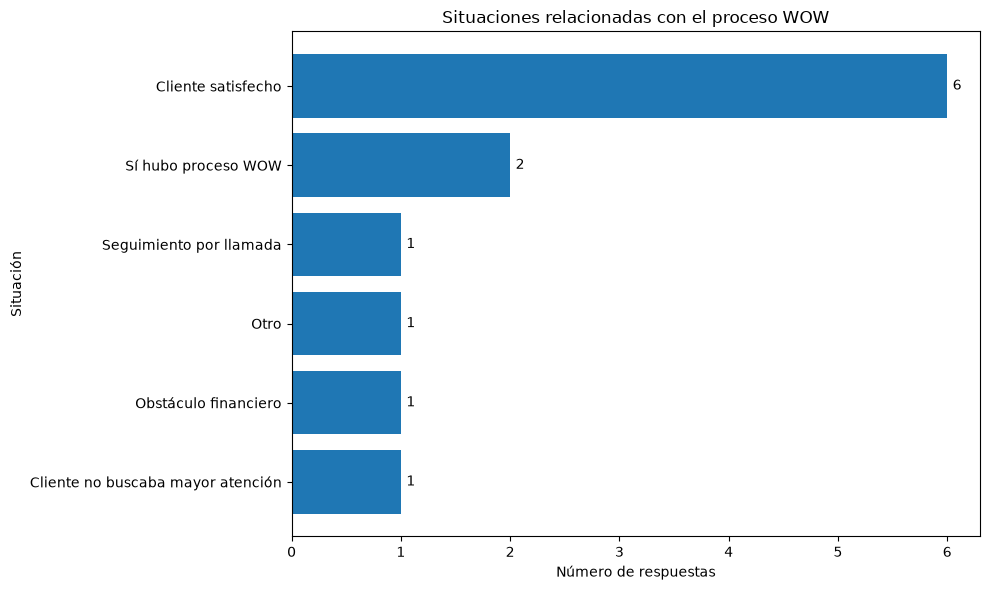

In [24]:

Filtro_index_wow = Filtro_index_wow.sort_values(
    by="count",
    ascending=True
)

plt.figure(figsize=(10, 6))

barras = plt.barh(
    Filtro_index_wow.index,
    Filtro_index_wow["count"]
)

for barra in barras:

    ancho = barra.get_width()

    plt.text(
        ancho + 0.05,
        barra.get_y() + barra.get_height()/2,
        int(ancho),
        va="center"
    )

plt.title("Situaciones relacionadas con el proceso WOW")
plt.xlabel("Número de respuestas")
plt.ylabel("Situación")

plt.tight_layout()
plt.show()